# 05.06 - Random Forests & Bagging

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

A single decision tree overfits. Random forests fix this by training many trees on random subsets of data and features, then averaging their predictions.

## 2. Why Does This Matter?

Random forests are one of the most popular ML algorithms. They work well out of the box, handle missing values, and provide feature importance.

## 3. Prerequisites

- 05.05: Decision trees

## 4. Learning Objectives

- Understand bagging (bootstrap aggregating)
- Implement bagging from scratch
- Apply random forests to real datasets

## 5. Mental Model

Bagging: Train each tree on a random sample (with replacement) of the data.
Random Forest: Bagging + random feature subsets at each split.
Prediction: Majority vote (classification) or average (regression).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Bagging from Scratch

Bootstrap Aggregating:
1. Draw n random samples with replacement from training data
2. Train a decision tree on each bootstrap sample
3. Average predictions across all trees

In [2]:
class BaggingClassifierScratch:
    """Bagging ensemble from scratch."""
    
    def __init__(self, n_estimators=10, max_depth=10, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = []
        self.bootstraps = []
    
    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        self.trees = []
        self.bootstraps = []
        
        for i in range(self.n_estimators):
            # Bootstrap sample
            indices = rng.choice(len(X), size=len(X), replace=True)
            X_boot, y_boot = X[indices], y[indices]
            self.bootstraps.append(indices)
            
            # Train tree
            tree = DecisionTreeClassifier(max_depth=self.max_depth, random_state=rng.randint(10000))
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
        
        return self
    
    def predict(self, X):
        # Majority vote
        predictions = np.array([tree.predict(X) for tree in self.trees])
        result = np.array([np.bincount(p.astype(int)).argmax() for p in predictions.T])
        return result
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print("BaggingClassifierScratch defined.")

BaggingClassifierScratch defined.


In [3]:
# Load Wine dataset
wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42
)

# Compare single tree vs bagging
single_tree = DecisionTreeClassifier(max_depth=10, random_state=42)
single_tree.fit(X_train, y_train)

bagging = BaggingClassifierScratch(n_estimators=50, max_depth=10, random_state=42)
bagging.fit(X_train, y_train)

print("=== Comparison ===")
print(f"Single Tree: Train={single_tree.score(X_train, y_train):.4f}, Test={single_tree.score(X_test, y_test):.4f}")
print(f"Bagging:     Train={bagging.score(X_train, y_train):.4f}, Test={bagging.score(X_test, y_test):.4f}")

=== Comparison ===
Single Tree: Train=1.0000, Test=0.9444
Bagging:     Train=1.0000, Test=0.9722


## 7. Random Forest

Random Forest = Bagging + Random Feature Selection

At each split, only consider sqrt(n_features) features (classification) or n_features/3 (regression). This decorrelates trees and reduces overfitting.

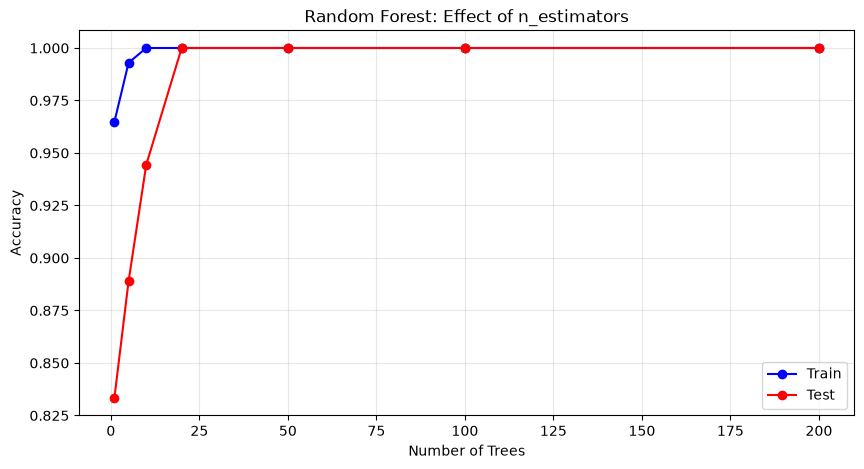

Test accuracy stabilizes around 50-100 trees.


In [4]:
# Effect of n_estimators
n_trees_range = [1, 5, 10, 20, 50, 100, 200]
train_scores = []
test_scores = []

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(n_trees_range, train_scores, 'b-o', label='Train')
plt.plot(n_trees_range, test_scores, 'r-o', label='Test')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest: Effect of n_estimators')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('rf_n_estimators.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Test accuracy stabilizes around 50-100 trees.")

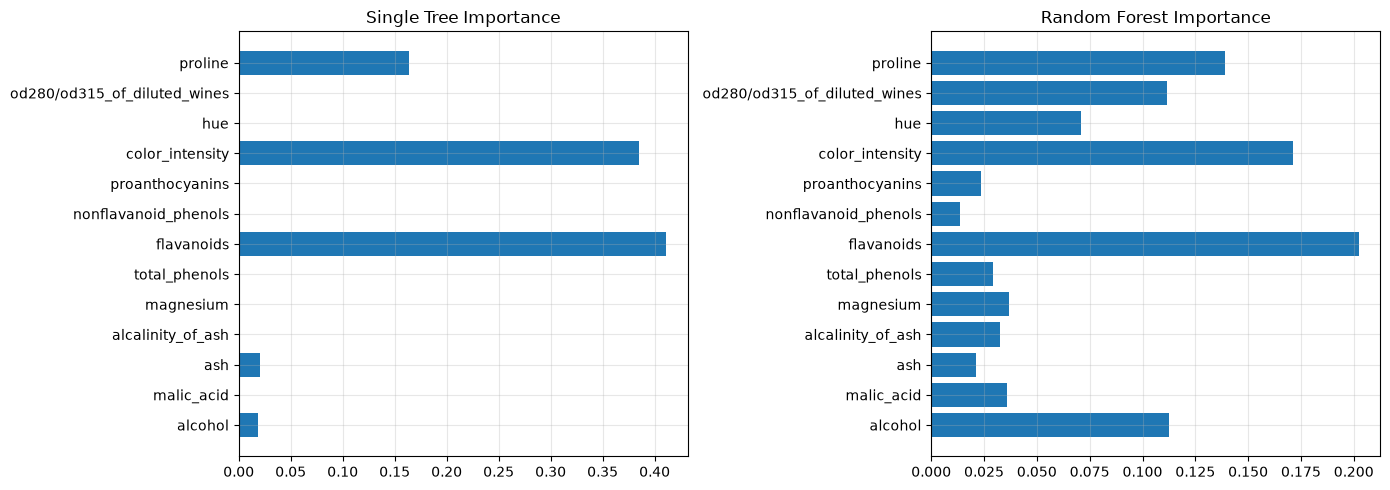

Random forest importance is smoother and more reliable.


In [5]:
# Feature importance comparison
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

tree_imp = single_tree.feature_importances_
rf_imp = rf.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(range(13), tree_imp)
axes[0].set_yticks(range(13))
axes[0].set_yticklabels(wine.feature_names)
axes[0].set_title('Single Tree Importance')
axes[0].grid(True, alpha=0.3)

axes[1].barh(range(13), rf_imp)
axes[1].set_yticks(range(13))
axes[1].set_yticklabels(wine.feature_names)
axes[1].set_title('Random Forest Importance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("Random forest importance is smoother and more reliable.")

## 8. Out-of-Bag (OOB) Score

Each tree is trained on ~63% of data (bootstrap). The remaining ~37% is "out-of-bag" and can be used for validation — no need for a separate test set!

In [6]:
# OOB score
rf_oob = RandomForestClassifier(n_estimators=100, max_depth=10, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"OOB Score: {rf_oob.oob_score_:.4f}")
print(f"Test Score: {rf_oob.score(X_test, y_test):.4f}")
print("(OOB is an unbiased estimate of generalization performance)")

OOB Score: 0.9648
Test Score: 1.0000
(OOB is an unbiased estimate of generalization performance)


## 9. Common Mistakes

1. **Not tuning max_depth** — deep trees still overfit in ensembles
2. **Using too few trees** — less than 10 gives unstable results
3. **Ignoring feature scaling** — RF doesn't need it, but downstream models might
4. **Trusting feature importance with correlated features** — they share importance

## 10. Coding Exercises

### Exercise 1: Bagging vs Random Forest
Compare BaggingClassifierScratch with sklearn RandomForestClassifier on the Wine dataset.

### Exercise 2: Titanic Random Forest
Load Titanic from seaborn. Train a random forest. Report accuracy and feature importance.

In [7]:
# EXERCISE 1: Compare bagging vs RF
print("Exercise: Compare your BaggingClassifierScratch with sklearn RandomForestClassifier")

Exercise: Compare your BaggingClassifierScratch with sklearn RandomForestClassifier


In [8]:
# EXERCISE 2: Titanic RF
import seaborn as sns
print("Exercise: Train a random forest on Titanic data.")

Exercise: Train a random forest on Titanic data.


## 11. Closed-Book Recall

1. What is bagging? Why does it reduce overfitting?
2. How does a random forest differ from bagging?
3. What is the OOB score?
4. How many features does each tree consider at each split?

## 12. Teach-Back Questions

Explain to another person:
- Why averaging many overfitting trees gives a good model.
- Why random feature selection helps.
- When random forests fail.

## 13. Summary

Random forests train many decision trees on bootstrap samples with random feature subsets. This decorrelates trees and reduces overfitting. Bagging reduces variance; random feature selection adds more diversity. OOB score provides free validation.

## 14. Further Experiment

1. Tune max_depth and n_estimators jointly with GridSearchCV.
2. Compare random forests on datasets with different numbers of features.
3. Implement a random forest regressor from scratch.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```